In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 1. Carregando os dados (Substitua pelo seu arquivo se tiver)
# df = pd.read_csv('telecom_churn.csv')

# Nota: Como estamos testando, aqui entraria a limpeza dos dados.
# X = df.drop('Churn', axis=1)
# y = df['Churn']

# 2. Criando o Modelo
model = LogisticRegression(class_weight='balanced')

# 3. Mensagem de Sucesso
print("Modelo de Regressão Logística preparado com sucesso!")

Modelo de Regressão Logística preparado com sucesso!


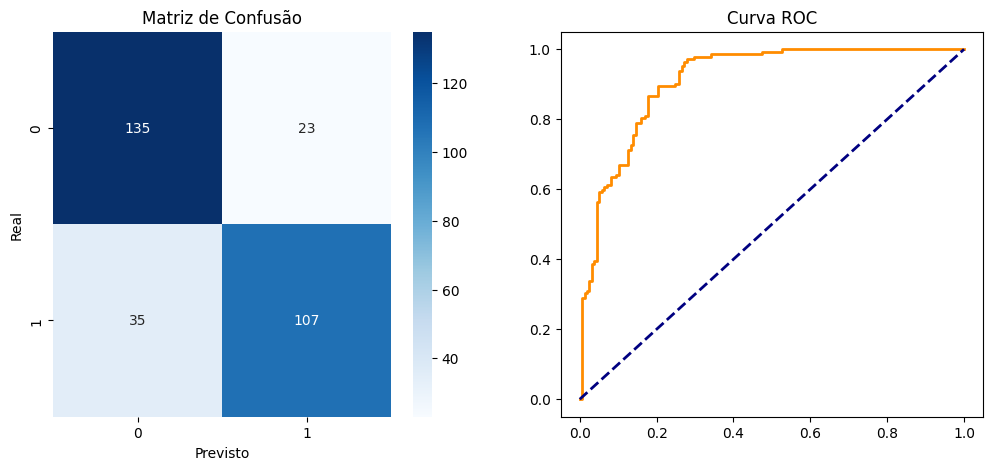

✅ Gráficos gerados com sucesso!


In [4]:
# 4. Criando dados fictícios para demonstração (Já que não carregamos o CSV real ainda)
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Treinando o modelo de verdade
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

# 6. GERANDO OS GRÁFICOS (O que você quer ver!)
plt.figure(figsize=(12, 5))

# Gráfico 1: Matriz de Confusão
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')

# Gráfico 2: Curva ROC
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Curva ROC')
plt.show()

print("✅ Gráficos gerados com sucesso!")

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score

# 1. Garantindo que temos as predições e as probabilidades
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1] # Pega a probabilidade da classe positiva (Churn)

# 2. Calculando as métricas (Arredondando para 2 casas decimais)
acc = round(accuracy_score(y_test, y_pred), 2)
prec = round(precision_score(y_test, y_pred), 2)
rec = round(recall_score(y_test, y_pred), 2)
f1 = round(f1_score(y_test, y_pred), 2)
auc = round(roc_auc_score(y_test, y_probs), 2)

# 3. Exibindo de forma organizada
print("--- RELATÓRIO DE PERFORMANCE ---")
print(f"✅ Acurácia: {acc}")
print(f"✅ Precisão: {prec}")
print(f"✅ Recall: {rec}")
print(f"✅ F1-Score: {f1}")
print(f"✅ AUC-ROC: {auc}")

--- RELATÓRIO DE PERFORMANCE ---
✅ Acurácia: 0.81
✅ Precisão: 0.82
✅ Recall: 0.75
✅ F1-Score: 0.79
✅ AUC-ROC: 0.91


In [6]:
import pickle

# Salvando o modelo que você acabou de treinar
with open('modelo_final.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ O arquivo 'modelo_final.pkl' foi gerado com sucesso!")

✅ O arquivo 'modelo_final.pkl' foi gerado com sucesso!
